Loading datasets from /home/raheemr/Desktop/Proj/...
Data loading and timestamp alignment complete.

Processing Volume...
Total missing Volume cells evaluated: 259,019


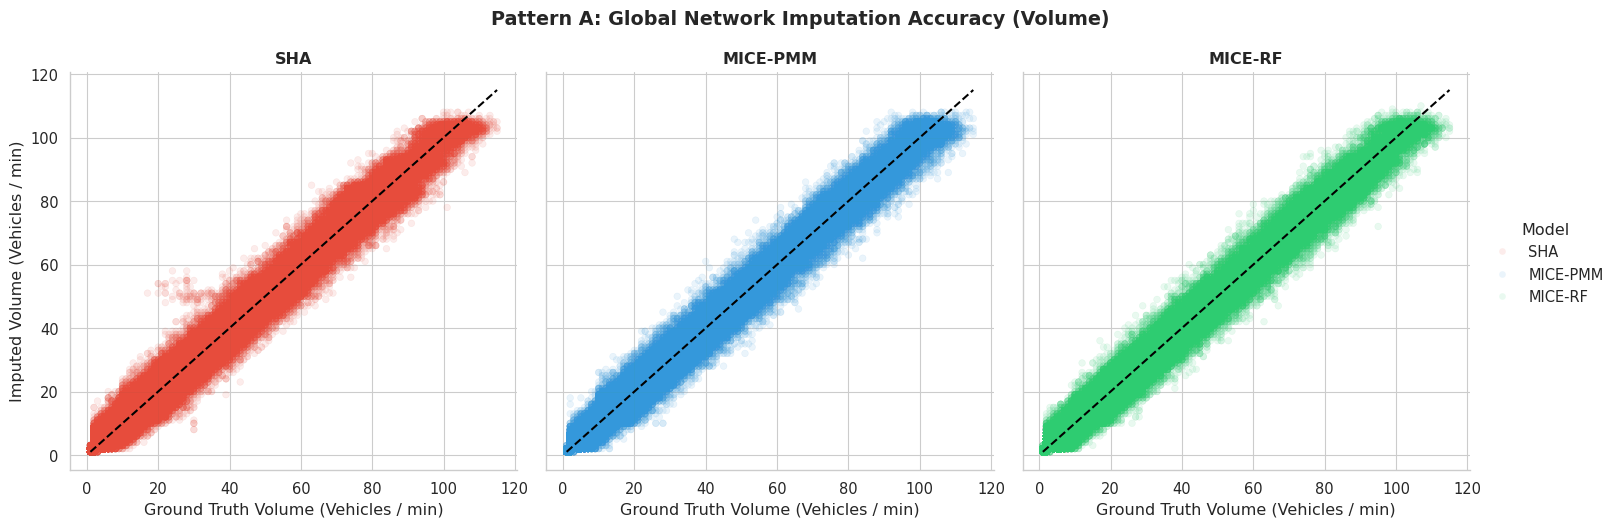

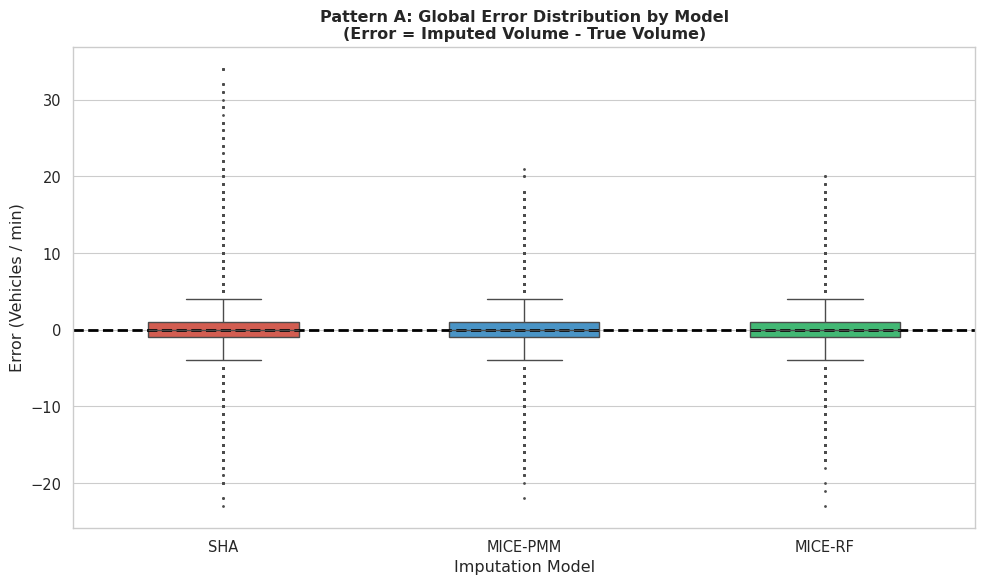

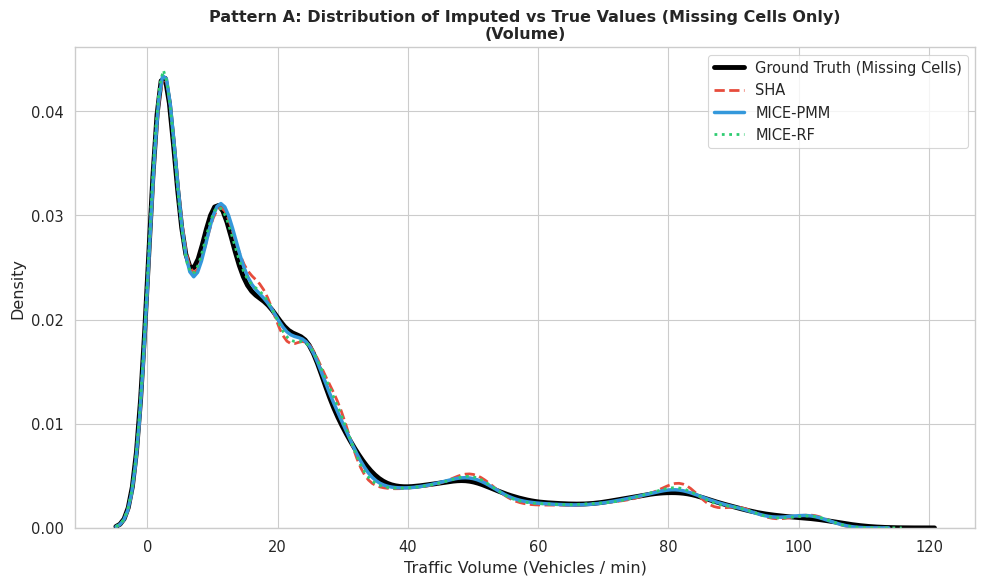

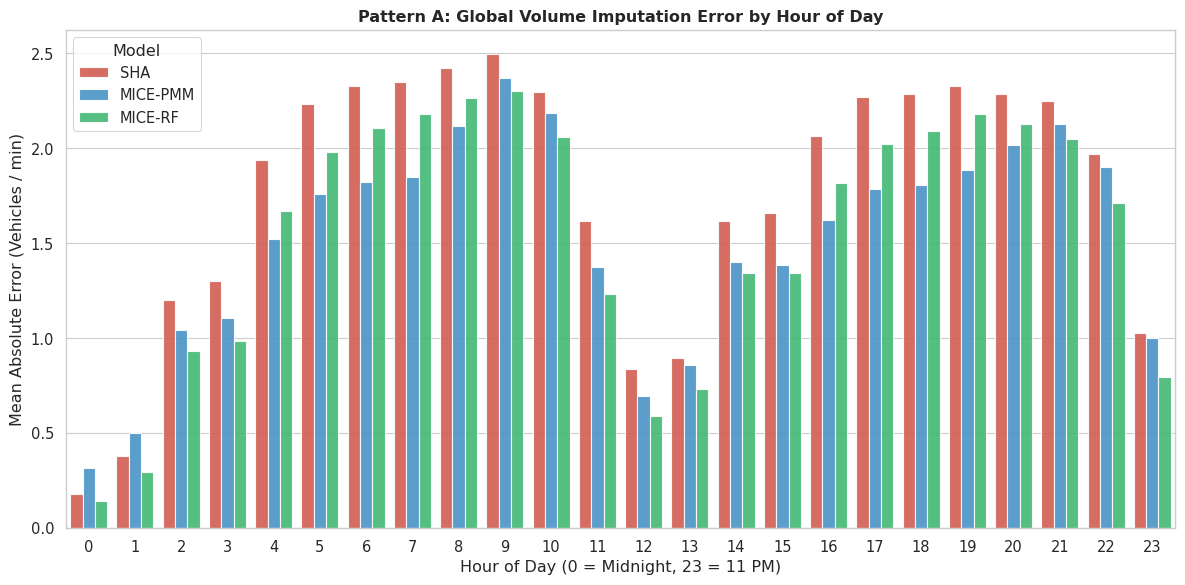


Processing Speed...
Total missing Speed cells evaluated: 260,199


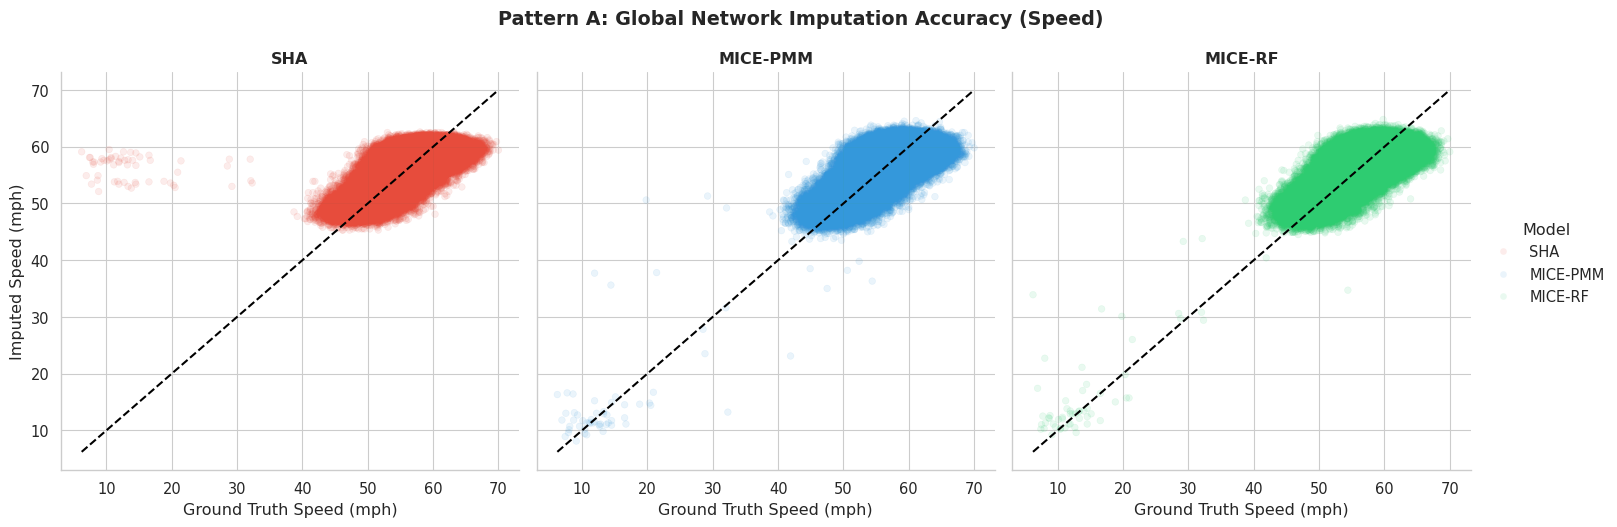

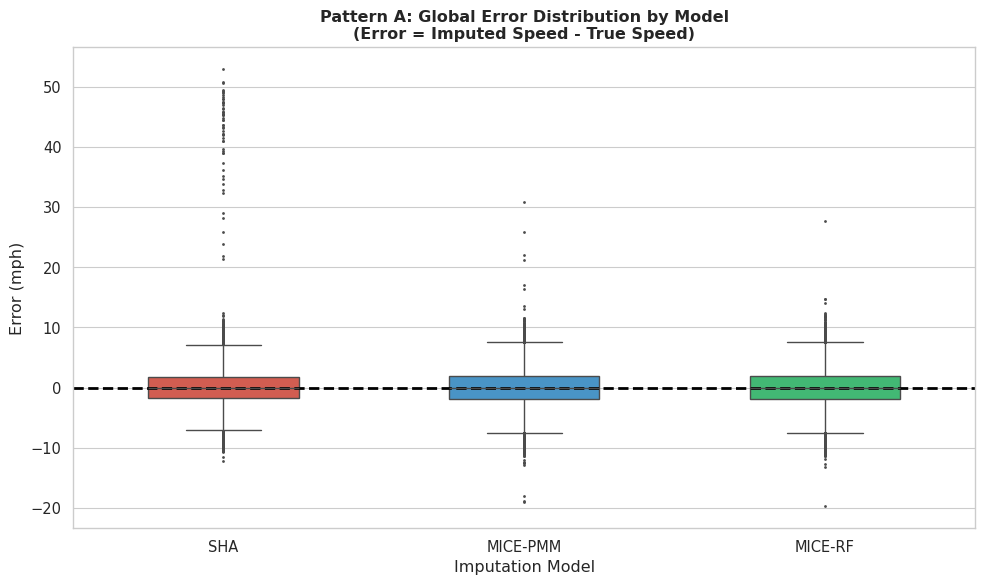

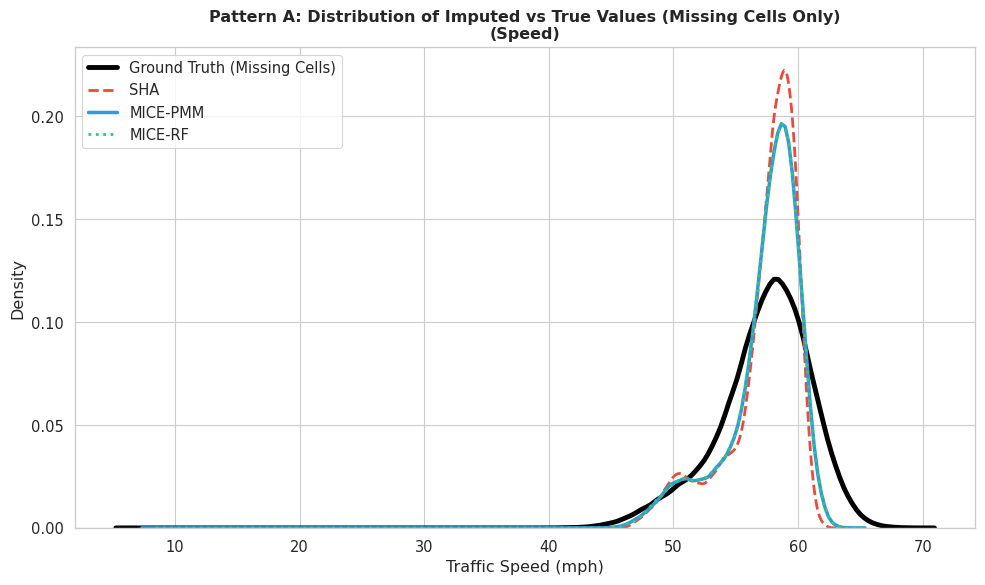

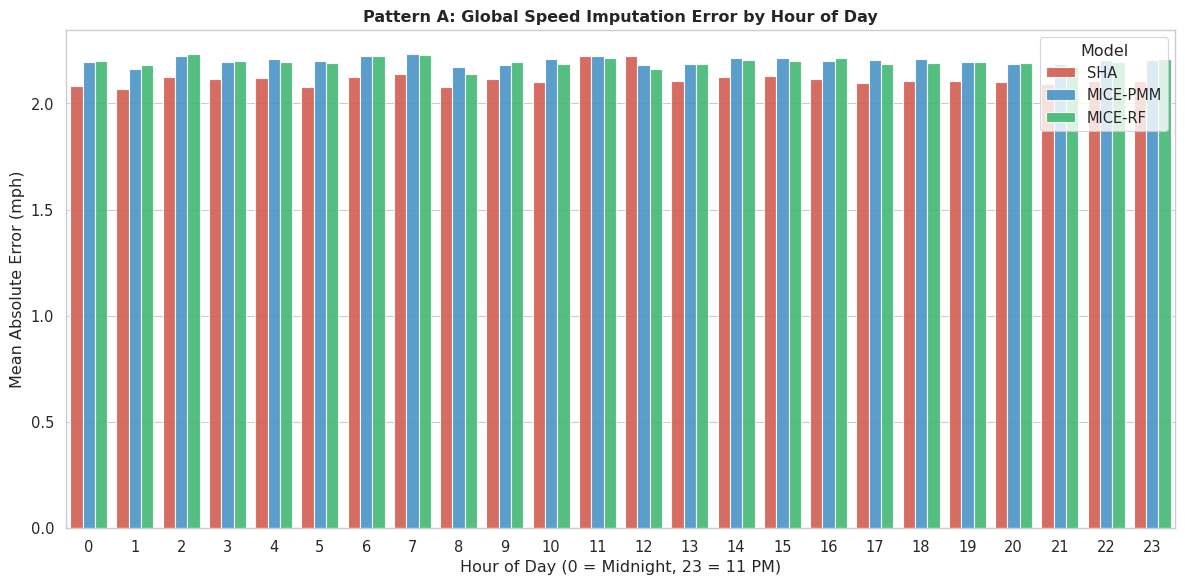

Generating Supervisor-Requested Single Hour Boxplot for Speed...


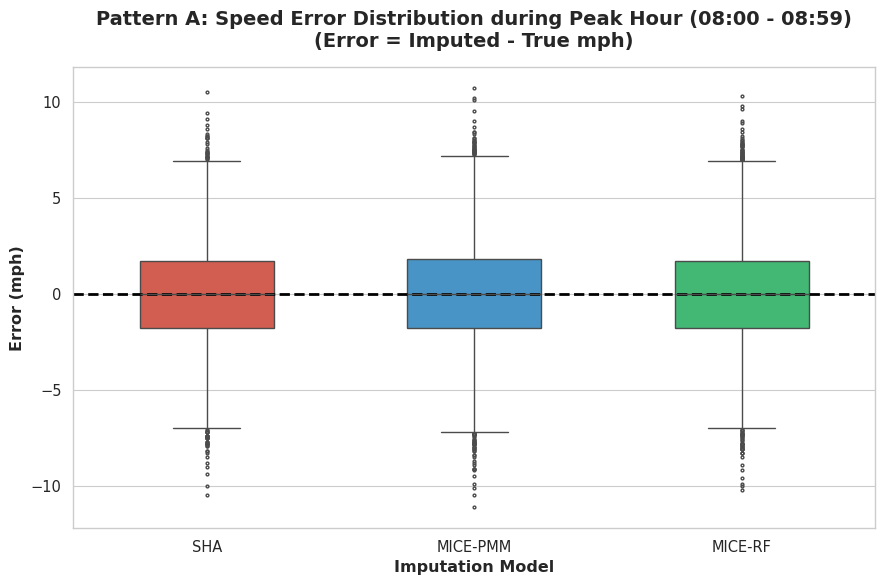


Generating TMT Macroeconomic Plot...


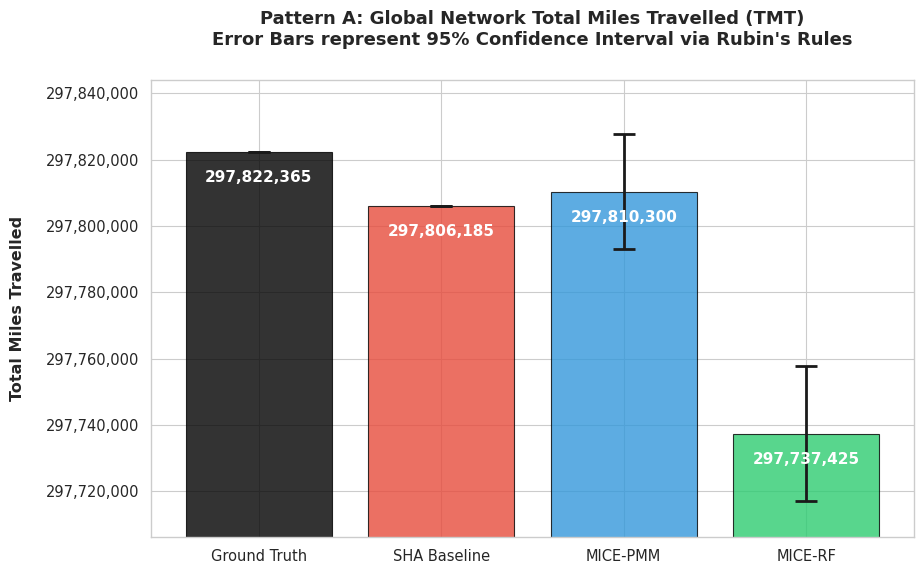

All plots generated successfully.


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os


# 1. GLOBAL SETTINGS 

sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)
PALETTE = {"SHA": "#e74c3c", "MICE-PMM": "#3498db", "MICE-RF": "#2ecc71"}


# 2. DATA LOADING & PREPROCESSING



def load_and_prep_data(data_dir):
    """Loads all CSVs and perfectly aligns timestamps across imputed datasets."""
    print(f"Loading datasets from {data_dir}...")
    
    # Load cell-level data using os.path.join
    truth_df = pd.read_csv(os.path.join(data_dir, 'MICE_wide_1jamnew.csv'))
    miss_df  = pd.read_csv(os.path.join(data_dir, 'traffic_mcar_10.csv'))
    
    models = {
        'SHA': pd.read_csv(os.path.join(data_dir, 'traffic_wide_SHA_patternA.csv')),
        'MICE-PMM': pd.read_csv(os.path.join(data_dir, 'patternA_MICE_PMM_pooled.csv')),
        'MICE-RF': pd.read_csv(os.path.join(data_dir, 'patternA_MICE_RF_pooled.csv'))
    }
    
    # Load TMT & Rubin's Rules data
    tmt_files = {
        'PMM_TMT': pd.read_csv(os.path.join(data_dir, 'patternA_TMT.csv')),
        'RF_TMT': pd.read_csv(os.path.join(data_dir, 'patternA_MICE_RF_TMT.csv')),
        'SHA_TMT': pd.read_csv(os.path.join(data_dir, 'sha_tmt_results_patternA.csv')),
        'PMM_Rubin': pd.read_csv(os.path.join(data_dir, 'patternA_Rubin_TMT.csv')),
        'RF_Rubin': pd.read_csv(os.path.join(data_dir, 'patternA_MICE_RF_Rubin_TMT.csv'))
    }

    # Timestamp Repair Fix
    truth_df['Timestamp'] = pd.to_datetime(truth_df['Timestamp'], dayfirst=True)
    miss_df['Timestamp']  = pd.to_datetime(truth_df['Timestamp'], dayfirst=True)

    for name, df in models.items():
        df['Timestamp'] = truth_df['Timestamp'].copy()
        df['DayOfWeek'] = truth_df['DayOfWeek'].copy()
        df['Hour']      = truth_df['Hour'].copy()
        df['Minute']    = truth_df['Minute'].copy()

    print("Data loading and timestamp alignment complete.")
    return truth_df, miss_df, models, tmt_files


# 3. DATA WRANGLING FUNCTION

def wrangle_comparison_data(truth_df, miss_df, models, prefix):
    """Melts and merges datasets to isolate missing cells for a specific prefix (Vol_ or Spd_)."""
    target_cols = [col for col in truth_df.columns if col.startswith(prefix)]
    
    truth_melt = truth_df.melt(id_vars=['Timestamp'], value_vars=target_cols, var_name='Sensor', value_name='Truth')
    miss_melt = miss_df.melt(id_vars=['Timestamp'], value_vars=target_cols, var_name='Sensor', value_name='Missing')

    # Find exactly where the missing cells are
    master_df = truth_melt.merge(miss_melt, on=['Timestamp', 'Sensor'])
    mask = master_df['Missing'].isna() & master_df['Truth'].notna()
    
    missing_cases = master_df[mask].copy()
    missing_cases['Hour'] = missing_cases['Timestamp'].dt.hour

    plot_data = []
    melted_models = {'Ground Truth': truth_melt['Truth']} # Store for KDE plot
    
    for model_name, imp_df in models.items():
        imp_melt = imp_df.melt(id_vars=['Timestamp'], value_vars=target_cols, var_name='Sensor', value_name='Imputed')
        melted_models[model_name] = imp_melt['Imputed']
        
        merged = missing_cases.merge(imp_melt, on=['Timestamp', 'Sensor'])
        merged['Error'] = merged['Imputed'] - merged['Truth']
        merged['Abs_Error'] = merged['Error'].abs()
        merged['Model'] = model_name
        plot_data.append(merged)

    comparison_df = pd.concat(plot_data, ignore_index=True)
    return comparison_df, melted_models


# 4. PLOTTING FUNCTIONS

def plot_scatter(df, var_name, unit):
    g = sns.relplot(
        data=df, x='Truth', y='Imputed', 
        col='Model', hue='Model', palette=PALETTE, 
        alpha=0.1, height=5, aspect=1, edgecolor=None
    )
    max_val, min_val = df[['Truth', 'Imputed']].max().max(), df[['Truth', 'Imputed']].min().min()
    
    for ax in g.axes.flat:
        ax.plot([min_val, max_val], [min_val, max_val], color='black', linestyle='--', linewidth=1.5)
        ax.set_title(ax.get_title().replace("Model = ", ""), fontweight='bold')

    g.set_axis_labels(f"Ground Truth {var_name} ({unit})", f"Imputed {var_name} ({unit})")
    g.fig.suptitle(f"Pattern A: Global Network Imputation Accuracy ({var_name})", y=1.05, fontweight='bold')
    plt.show()

def plot_error_boxplot(df, var_name, unit):
    plt.figure(figsize=(10, 6))
    ax = sns.boxplot(x="Model", y="Error", data=df, hue= "Model", palette=PALETTE, width=0.5, fliersize=1, legend=False)
    ax.axhline(0, color='black', linestyle='--', linewidth=2) 
    ax.set_title(f"Pattern A: Global Error Distribution by Model\n(Error = Imputed {var_name} - True {var_name})", fontweight='bold')
    ax.set_ylabel(f"Error ({unit})")
    ax.set_xlabel("Imputation Model")
    plt.tight_layout()
    plt.show()

def plot_kde_density(df, var_name, unit):
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # Extract the ground truth for JUST the missing cells
    truth_data = df[df['Model'] == 'SHA']['Truth']
    
    sns.kdeplot(data=truth_data, color="black", label="Ground Truth (Missing Cells)", linewidth=3.5, ax=ax)
    sns.kdeplot(data=df[df['Model'] == 'SHA']['Imputed'], color="#e74c3c", label="SHA", linewidth=2, linestyle="--", ax=ax)
    sns.kdeplot(data=df[df['Model'] == 'MICE-PMM']['Imputed'], color="#3498db", label="MICE-PMM", linewidth=2.5, ax=ax)
    sns.kdeplot(data=df[df['Model'] == 'MICE-RF']['Imputed'], color="#2ecc71", label="MICE-RF", linewidth=2, linestyle=":", ax=ax)

    
    ax.set_title(f"Pattern A: Distribution of Imputed vs True Values (Missing Cells Only)\n({var_name})", fontweight='bold')
    ax.set_xlabel(f"Traffic {var_name} ({unit})")
    ax.set_ylabel("Density")
    ax.legend()
    plt.tight_layout()
    plt.show()

def plot_hourly_error(df, var_name, unit):
    plt.figure(figsize=(12, 6))
    ax = sns.barplot(
        x="Hour", y="Abs_Error", hue="Model", 
        data=df, palette=PALETTE, errorbar=None, alpha=0.9
    )
    ax.set_title(f"Pattern A: Global {var_name} Imputation Error by Hour of Day", fontweight='bold')
    ax.set_ylabel(f"Mean Absolute Error ({unit})")
    ax.set_xlabel("Hour of Day (0 = Midnight, 23 = 11 PM)")
    plt.legend(title="Model")
    plt.tight_layout()
    plt.show()

def plot_tmt_hero(tmt_files):
    tmt_rf  = tmt_files['RF_TMT']
    tmt_pmm = tmt_files['PMM_TMT']
    sha_tmt = tmt_files['SHA_TMT']

    tmt_true = tmt_rf.loc[tmt_rf['Dataset'] == 'GroundTruth', 'TMT'].values[0]
    tmt_sha_val = sha_tmt.loc[sha_tmt['Dataset'] == 'SHA_Imputed', 'Total_Miles_Travelled'].values[0]
    tmt_pmm_val = tmt_pmm.loc[tmt_pmm['Dataset'] == 'MICE_PMM_pooled', 'TMT'].values[0]
    tmt_rf_val  = tmt_rf.loc[tmt_rf['Dataset'] == 'MICE_RF_pooled', 'TMT'].values[0]

    se_pmm = tmt_files['PMM_Rubin']['Total_SE'].values[0]
    se_rf  = tmt_files['RF_Rubin']['Total_SE'].values[0]

    # Adjusted figsize slightly 
    fig, ax = plt.subplots(figsize=(10, 6.5)) 
    labels = ['Ground Truth', 'SHA Baseline', 'MICE-PMM', 'MICE-RF']
    values = [tmt_true, tmt_sha_val, tmt_pmm_val, tmt_rf_val]
    errors = [0, 0, se_pmm * 1.96, se_rf * 1.96] 
    colors = ["black", "#e74c3c", "#3498db", "#2ecc71"]

    bars = ax.bar(labels, values, yerr=errors, capsize=8, color=colors, alpha=0.8, 
                  edgecolor='black', error_kw=dict(lw=2, capthick=2))

    # DYNAMIC Y-LIMIT FIX INCLUDING ERROR BARS 
    max_reach = max([val + err for val, err in zip(values, errors)])
    min_reach = min([val - err for val, err in zip(values, errors)])
    total_span = max_reach - min_reach

    # Set limits with 10% padding bottom and 15% padding top
    ax.set_ylim(min_reach - (total_span * 0.10), max_reach + (total_span * 0.15))

    # Position text dynamically inside the bars based on the total visual span
    for bar in bars:
        yval = bar.get_height()
        inside_y_position = yval - (total_span * 0.05)
        ax.text(bar.get_x() + bar.get_width()/2, inside_y_position, 
                f'{int(yval):,}', ha='center', va='top', color='white', fontweight='bold', fontsize=11)

    ax.set_title("Pattern A: Global Network Total Miles Travelled (TMT)\nError Bars represent 95% Confidence Interval via Rubin's Rules", 
                 fontweight='bold', pad=25, fontsize=13)
    ax.set_ylabel("Total Miles Travelled", fontweight='bold', labelpad=15)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: format(int(x), ',')))

    plt.tight_layout(pad=3.0)
    plt.show()

def plot_single_hour_error_boxplot(df, var_name, unit, target_hour=8):
    """
    Generates a boxplot of imputation errors for a single specific hour.
    Default target_hour is 8 (8:00 AM - 8:59 AM).
    """
    # Filter the dataframe for the specific hour
    df_hour = df[df['Hour'] == target_hour].copy()
    
    # Format the hour for the title 
    time_label = f"{target_hour:02d}:00 - {target_hour:02d}:59"
    
    plt.figure(figsize=(9, 6))
    ax = sns.boxplot(
        x="Model", y="Error", data=df_hour, hue="Model", 
        palette=PALETTE, width=0.5, fliersize=2, legend=False
    )
    
    # Add a bold dashed line at exactly 0 error (perfect imputation)
    ax.axhline(0, color='black', linestyle='--', linewidth=2) 
    
    ax.set_title(f"Pattern A: {var_name} Error Distribution during Peak Hour ({time_label})\n(Error = Imputed - True {unit})", fontweight='bold', fontsize=14, pad=15)
    ax.set_ylabel(f"Error ({unit})", fontweight='bold')
    ax.set_xlabel("Imputation Model", fontweight='bold')
    
    plt.tight_layout()
    plt.show()


# 5. MAIN EXECUTION

if __name__ == "__main__":

    path_to_data = "/home/raheemr/Desktop/Proj/"
    

    truth_df, miss_df, models, tmt_files = load_and_prep_data(path_to_data)
    

    # Define variables to iterate over
    metrics = [
        {"prefix": "Vol_", "name": "Volume", "unit": "Vehicles / min"},
        {"prefix": "Spd_", "name": "Speed", "unit": "mph"}
    ]

    # Generate plots for both Volume and Speed dynamically
    for metric in metrics:
        print(f"\nProcessing {metric['name']}...")
        comp_df, melted_dict = wrangle_comparison_data(truth_df, miss_df, models, metric['prefix'])
        
        print(f"Total missing {metric['name']} cells evaluated: {len(comp_df) // 3:,}")
        
        plot_scatter(comp_df, metric['name'], metric['unit'])
        plot_error_boxplot(comp_df, metric['name'], metric['unit'])
        plot_kde_density(comp_df, metric['name'], metric['unit'])
        plot_hourly_error(comp_df, metric['name'], metric['unit'])

        # Focus on Hour 8 (Morning Rush Hour)
        if metric['name'] == "Speed":
            print("Generating Supervisor-Requested Single Hour Boxplot for Speed...")
            plot_single_hour_error_boxplot(comp_df, metric['name'], metric['unit'], target_hour=8)

    # Generate the final TMT Hero Plot
    print("\nGenerating TMT Macroeconomic Plot...")
    plot_tmt_hero(tmt_files)
    print("All plots generated successfully.")
    